Validation of the new $^{83\text{m}}\text{Kr}$ calibration called _Zemrude_.


Here, we compare two merged and processed dataframes from the second period of low-background LPR. Both dataframes are processed in the same way, just changing the calibration (Icaros and Zemrude). We study the performance of these calibration in terms of energy, in particular for the double escape peak (DEP).

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# --- NOTEBOOK PARAMETERS --- #
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS =  ['data', 'icaros_data']
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

In [3]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/low_bckg_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        input_dir   = common_config['input_dir']
        summary_dir = common_config['summary_dir']
        input_path   = os.path.join(input_dir,   ana_config[ana_type]['processed_file'])
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file'])
        print(f"  Input file path   : {input_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_events  = pd.read_hdf(input_path, key=common_config['evt_key'])
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'df_processed' : df_events
                             , 'df_summary'   : df_summary
                             , 'duration'     : ana_config[ana_type]['duration']
                             , 'he_scale'     : ana_config[ana_type]['he_scale'] }

        print(f"Loaded successfully.\n")

# ----------------
# GLOBAL CONSTANTS
# ----------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# Geometric boundaries for fiducial volume
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# DEP Value
DEP_VALUE = 1.593   # MeV

----- Loading configuration for DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_runs_castle_closed_RAS_p2_zemrude_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_zemrude_v2_processed.csv
Loaded successfully.

----- Loading configuration for ICAROS_DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_runs_castle_closed_RAS_p2_icaros_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_icaros_v2_processed.csv
Loaded successfully.



# Reconstructed

In [4]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_processed']
    m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
    b_he_scale = ANA_INFO[ana_type]['he_scale']['b']

    # --- Electron-like Cut --- #
    df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    # --- HE Scale --- #
    df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
    df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

    # Update
    ANA_INFO[ana_type]['df_reco']    = df_temp

# Selection

## Inclusive ($nS2=1$)

In [5]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_reco']

    # --- nS2 = 1 Cut --- #
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # Update
    ANA_INFO[ana_type]['df_inclusive'] = df_temp

## Fiducial

In [6]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_inclusive']

    # --- Fiducial Volume Cut --- #
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # Update
    ANA_INFO[ana_type]['df_fiducial'] = df_temp

# Energy Analysis

In [7]:
ANA_INFO['icaros_data'].keys()

dict_keys(['df_processed', 'df_summary', 'duration', 'he_scale', 'df_reco', 'df_inclusive', 'df_fiducial'])


DATA:
  Counts = 10868, corr. time = 3485614.53 s | Rate = 3.1180 mHz
  Center of the DEP bin: 1.5900 MeV
  Shift value: -0.0030 MeV

ICAROS_DATA:
  Counts = 11639, corr. time = 3485614.53 s | Rate = 3.3392 mHz
  Center of the DEP bin: 1.6500 MeV
  Shift value: 0.0570 MeV


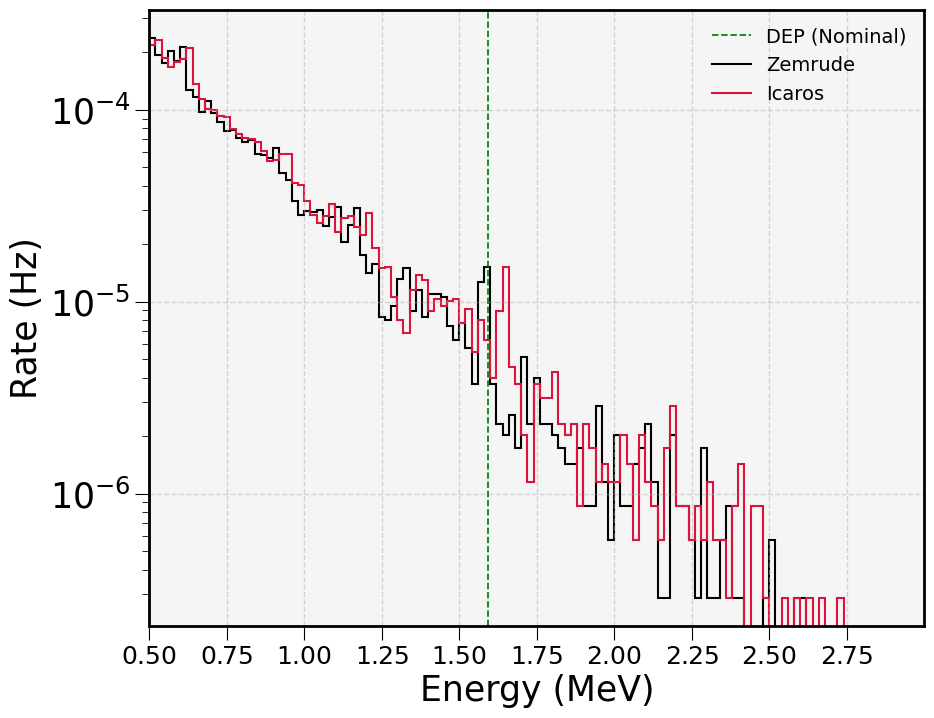

In [18]:
# Global
n_bins = 125
DEP_peak_hist = {}

# ----- Define the Binning ----- #
# Dataframes
FIDU_ICAROS_DF  = ANA_INFO['icaros_data']['df_fiducial']
hist_range = (FIDU_ICAROS_DF['E_final'].min(), 3)
_, plot_edges = np.histogram(FIDU_ICAROS_DF['E_final'], bins=n_bins, range=hist_range)

for i, ana_type in enumerate(ANA_INFO.keys()):

    dataframe = ANA_INFO[ana_type]['df_fiducial']
    duration  = ANA_INFO[ana_type]['duration']

    if ana_type == 'icaros_data': label = 'Icaros'
    elif ana_type == 'data'     : label = 'Zemrude'

    # Variable
    # E_evt = dataframe['E_evt_mev'] - shift_value
    E_evt = dataframe['E_final']

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / duration     # in [Hz]
    print(f"\n{ana_type.upper()}:\n  Counts = {counts.sum()}, corr. time = {duration:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")

    # ----- DEP Histogram Peak ----- #
    mask = (bin_edges[:-1] >= 1.50) & (bin_edges[:-1] <= 1.75)  
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Find the bin with the highest count in the specified range
    peak_bin_index  = np.argmax(counts[mask])
    peak_bin_center = bin_centers[mask][peak_bin_index]
    shift_value = peak_bin_center - DEP_VALUE
    DEP_peak_hist[ana_type] = peak_bin_center
    print(f"  Center of the DEP bin: {peak_bin_center:.4f} MeV")
    print(f"  Shift value: {shift_value:.4f} MeV")
    
    # ----- Plotting ----- #
    # Data
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    # line
    # plt.axvline(peak_bin_center, c='gray', ls='--', lw=1.0)

# Lines
plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.25, label='DEP (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(hist_range[0], hist_range[1])
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=18)
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()


ZEMRUDE:
  Fit range = (1.4875, 1.6875) MeV
    - μ guess = 1.5875 MeV
  Fit results:
    - μ = (1.5815 ± 0.0014) MeV
    - σ = (0.0091 ± 0.0015) MeV
    - R = (1.35 ± 0.22)%

ICAROS:
  Fit range = (1.5375, 1.7375) MeV
    - μ guess = 1.6375 MeV
  Fit results:
    - μ = (1.6475 ± 0.0021) MeV
    - σ = (0.0106 ± 0.0025) MeV
    - R = (1.51 ± 0.35)%


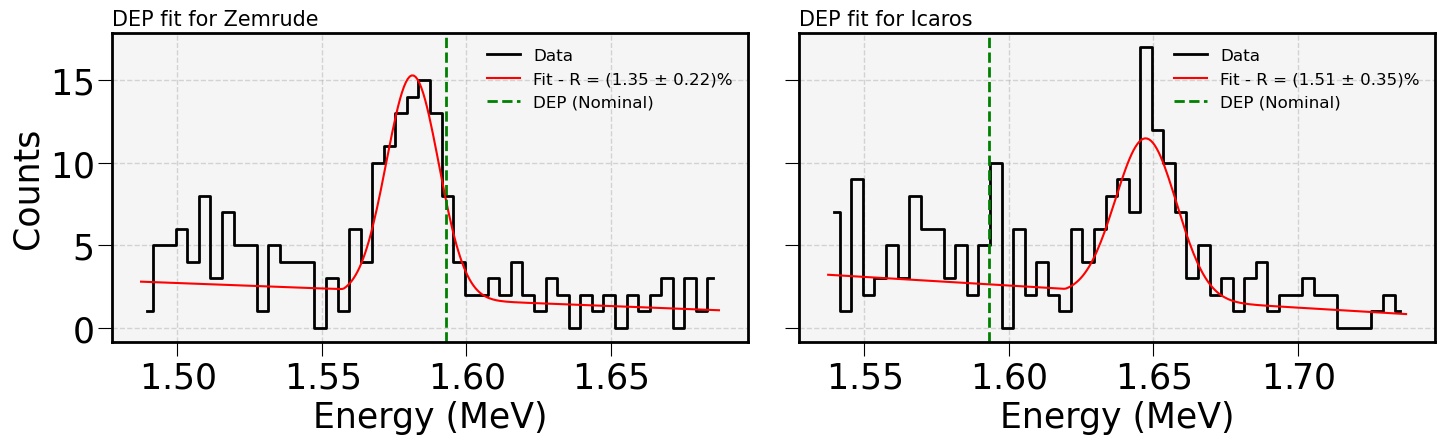

In [9]:
# Global
n_bins = 50
fig, axes = plt.subplots(1, len(ANA_INFO.keys()), figsize=(15, 5), sharey=True)

for i, (ana_type, ax) in enumerate(zip(ANA_INFO.keys(), axes)):

   dataframe = ANA_INFO[ana_type]['df_fiducial']
   mu_guess  = DEP_peak_hist[ana_type]

   if ana_type == 'icaros_data': label = 'Icaros'
   elif ana_type == 'data'     : label = 'Zemrude'

   print(f"\n{label.upper()}:")
   # ----- Fitting ----- #
   energy_data = dataframe['E_final']
   fit_range   = (mu_guess - 0.1, mu_guess + 0.1)
   print(f"  Fit range = ({fit_range[0]:.4f}, {fit_range[1]:.4f}) MeV")
   print(f"    - μ guess = {mu_guess:.4f} MeV")
   popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(energy_data, mu_guess, fit_range, bins=n_bins)

   if popt is not None:
      # Results
      mu, sigma = popt[1], abs(popt[2])
      mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
      res_cv = 2.355 * sigma / mu * 100
      res_err = res_cv * np.sqrt((sigma_err / sigma) ** 2 + (mu_err / mu) ** 2) if sigma > 0 else np.nan
      print(f"  Fit results:\n    - μ = ({mu:.4f} ± {mu_err:.4f}) MeV\n    - σ = ({sigma:.4f} ± {sigma_err:.4f}) MeV\n    - R = ({res_cv:.2f} ± {res_err:.2f})%")
      
      # --- Plotting --- #
      # Data
      ax.step(hist_counts, hist_bins, where='mid', label='Data')
      
      # Fit
      fit_x = np.linspace(fit_range[0], fit_range[-1], 300)
      ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt),
              color='red', ls='-', lw=1.5, label=f'Fit - R = ({res_cv:.2f} ± {res_err:.2f})%')

   # --- Styling --- #
   ax.axvline(DEP_VALUE, c='green', ls='--', lw=2, label='DEP (Nominal)')
   ax.set_title(f'DEP fit for {label}', fontsize=15, loc='left')
   ax.set_xlabel('Energy (MeV)')
   ax.legend(fontsize=12, facecolor='none')
   ax.grid(True)
   ax.set_facecolor("whitesmoke")

axes[0].set_ylabel('Counts')
plt.tight_layout()
plt.show()